In [168]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, Binarizer, KBinsDiscretizer
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

warnings.filterwarnings("ignore")

# Preparation

In [169]:
# Configuration

RANDOM_STATE = 42
TEST_SIZE = 0.20

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.float_format",
    lambda x: f"{x:.4f}"
)

# Load the data and quick explore

In [170]:
# Load the data

train = pd.read_csv("titanic/train.csv")
test = pd.read_csv("titanic/test.csv")

# Preserve raw values for the before-and-after cleaning comparison.
train_before_cleaning = train.copy(deep=True)
test_before_cleaning = test.copy(deep=True)

print("TRAIN INFO")
display(train.describe())

print("TEST INFO")
display(test.describe())

TRAIN INFO


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.0000,891.0000,891.0000,714.0000,891.0000,891.0000,891.0000
mean,446.0000,0.3838,2.3086,29.6991,0.5230,0.3816,32.2042
std,257.3538,0.4866,0.8361,14.5265,1.1027,0.8061,49.6934
min,1.0000,0.0000,1.0000,0.4200,0.0000,0.0000,0.0000
25%,223.5000,0.0000,2.0000,20.1250,0.0000,0.0000,7.9104
50%,446.0000,0.0000,3.0000,28.0000,0.0000,0.0000,14.4542
75%,668.5000,1.0000,3.0000,38.0000,1.0000,0.0000,31.0000
max,891.0000,1.0000,3.0000,80.0000,8.0000,6.0000,512.3292


TEST INFO


,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.0000,418.0000,332.0000,418.0000,418.0000,417.0000
mean,1100.5000,2.2656,30.2726,0.4474,0.3923,35.6272
std,120.8105,0.8418,14.1812,0.8968,0.9814,55.9076
min,892.0000,1.0000,0.1700,0.0000,0.0000,0.0000
25%,996.2500,1.0000,21.0000,0.0000,0.0000,7.8958
50%,1100.5000,3.0000,27.0000,0.0000,0.0000,14.4542
75%,1204.7500,3.0000,39.0000,1.0000,0.0000,31.5000
max,1309.0000,3.0000,76.0000,8.0000,9.0000,512.3292


In [209]:
missing = pd.DataFrame({
    "Train": train.isnull().sum(),
    "Test": test.isnull().sum()
})

duplicates = pd.DataFrame({
    "Train": [train.duplicated().sum()],
    "Test": [test.duplicated().sum()]
}, index=["Duplicate rows"])

summary = pd.concat([missing, duplicates]).astype("Int64")

display(summary)

,Train,Test
Age,177,86
Cabin,687,327
Embarked,2,0
Fare,0,1
Name,0,0
Parch,0,0
PassengerId,0,0
Pclass,0,0
Sex,0,0
SibSp,0,0


# Quick Data Cleaning
Cleaning is performed before the train/validation split for operations that do not learn parameters from the data. Missing-value imputation, scaling, and encoding are handled later inside model-specific pipelines so that those parameters are learned from the training split only.

In [172]:
# Standardize text formatting
for df in [train, test]:

    for col in ["Name", "Sex", "Ticket", "Cabin", "Embarked"]:
        df[col] = df[col].apply(
            lambda x: x.strip() if isinstance(x, str) else x
        )

    df["Sex"] = df["Sex"].str.lower()
    df["Embarked"] = df["Embarked"].str.upper()

# Replace impossible numerical values with missing
for df in [train, test]:

    df.loc[df["Age"] < 0, "Age"] = np.nan
    df.loc[df["Fare"] < 0, "Fare"] = np.nan
    df.loc[df["SibSp"] < 0, "SibSp"] = np.nan
    df.loc[df["Parch"] < 0, "Parch"] = np.nan

## Before and after: quick cleaning
Compare the raw CSV values with the fixed-rule cleaning above. The summary counts actual changes, treating two missing values as unchanged. Text examples use quotes so whitespace is visible. If no values changed, no artificial examples are introduced.

In [173]:
cleaning_example_rows = []
for dataset, before, after in [
    ("Train", train_before_cleaning, train),
    ("Test", test_before_cleaning, test),
]:
    for column in [
        "Name", "Sex", "Ticket", "Cabin", "Embarked",
        "Age", "Fare", "SibSp", "Parch"
    ]:
        unchanged = (
            before[column].eq(after[column])
            | (before[column].isna() & after[column].isna())
        )
        changed = ~unchanged
        for idx in before.index[changed][:5]:
            cleaning_example_rows.append({
                "Dataset": dataset,
                "PassengerId": before.loc[idx, "PassengerId"],
                "Column": column,
                "Before": repr(before.loc[idx, column]),
                "After": repr(after.loc[idx, column]),
            })
display(pd.DataFrame(cleaning_example_rows))

,Dataset,PassengerId,Column,Before,After
0,Train,16,Name,"'Hewlett, Mrs. (Mary D Kingcome) '","'Hewlett, Mrs. (Mary D Kingcome)'"
1,Train,858,Name,"'Daly, Mr. Peter Denis '","'Daly, Mr. Peter Denis'"
2,Test,1167,Name,"'Bryhl, Miss. Dagmar Jenny Ingeborg '","'Bryhl, Miss. Dagmar Jenny Ingeborg'"
3,Test,1222,Name,"'Davies, Mrs. John Morgan (Elizabeth Agnes Mar...","'Davies, Mrs. John Morgan (Elizabeth Agnes Mar..."


# TRAIN / VALIDATION SPLIT

In [174]:
# Separate target from predictors
X = train.drop(columns=["Survived"])
y = train["Survived"]

# Split the labeled training data
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)

Training set: (712, 11)
Validation set: (179, 11)


# Training Set Data Exploration

In [175]:
# ============================================
# DATA EXPLORATION — TRAINING SET
# ============================================

print("TRAINING SET INFO")
print("=" * 60)
X_train.info()

TRAINING SET INFO
<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Pclass       712 non-null    int64  
 2   Name         712 non-null    object 
 3   Sex          712 non-null    object 
 4   Age          575 non-null    float64
 5   SibSp        712 non-null    float64
 6   Parch        712 non-null    float64
 7   Ticket       712 non-null    object 
 8   Fare         712 non-null    float64
 9   Cabin        160 non-null    object 
 10  Embarked     710 non-null    object 
dtypes: float64(4), int64(2), object(5)
memory usage: 66.8+ KB


In [176]:
# ============================================
# MISSING VALUES — TRAINING SET
# ============================================

missing_train = pd.DataFrame({
    "Missing Count": X_train.isnull().sum(),
    "Missing Percentage": X_train.isnull().mean() * 100
})

display(
    missing_train
    .sort_values("Missing Percentage", ascending=False)
)

,Missing Count,Missing Percentage
Cabin,552,77.5281
Age,137,19.2416
Embarked,2,0.2809
PassengerId,0,0.0000
Pclass,0,0.0000
Name,0,0.0000
Sex,0,0.0000
SibSp,0,0.0000
Parch,0,0.0000
Ticket,0,0.0000


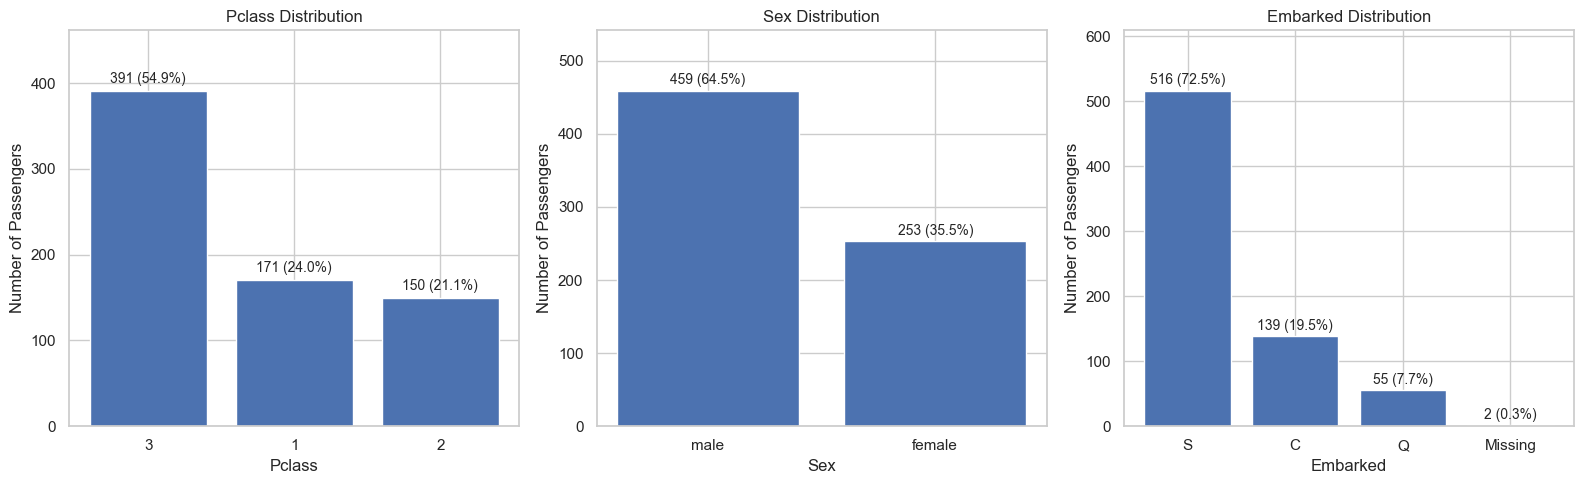

In [177]:
# ============================================
# CATEGORICAL VARIABLES — TRAINING SET
# ============================================

categorical_features = [
    "Pclass",
    "Sex",
    "Embarked"
]

fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 5)
)

for ax, column in zip(axes, categorical_features):

    # Counts
    counts = X_train[column].value_counts(dropna=False)

    # Percentages
    percentages = (
        X_train[column]
        .value_counts(dropna=False, normalize=True)
        * 100
    )

    # Convert missing values to a readable label
    labels = [
        "Missing" if pd.isna(value) else str(value)
        for value in counts.index
    ]

    # Plot
    bars = ax.bar(
        labels,
        counts.values
    )

    ax.set_title(f"{column} Distribution")
    ax.set_xlabel(column)
    ax.set_ylabel("Number of Passengers")

    # Add count and percentage to each bar
    for bar, count, percentage in zip(
        bars,
        counts.values,
        percentages.values
    ):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            f"{count} ({percentage:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=10
        )

    # Leave room for labels
    ax.set_ylim(
        0,
        max(counts.values) * 1.18
    )

plt.tight_layout()
plt.show()

,Feature,Skewness,Absolute Skewness,Interpretation
1,Fare,4.6462,4.6462,Strongly skewed
2,SibSp,3.8156,3.8156,Strongly skewed
3,Parch,2.8426,2.8426,Strongly skewed
0,Age,0.3533,0.3533,Approximately symmetric


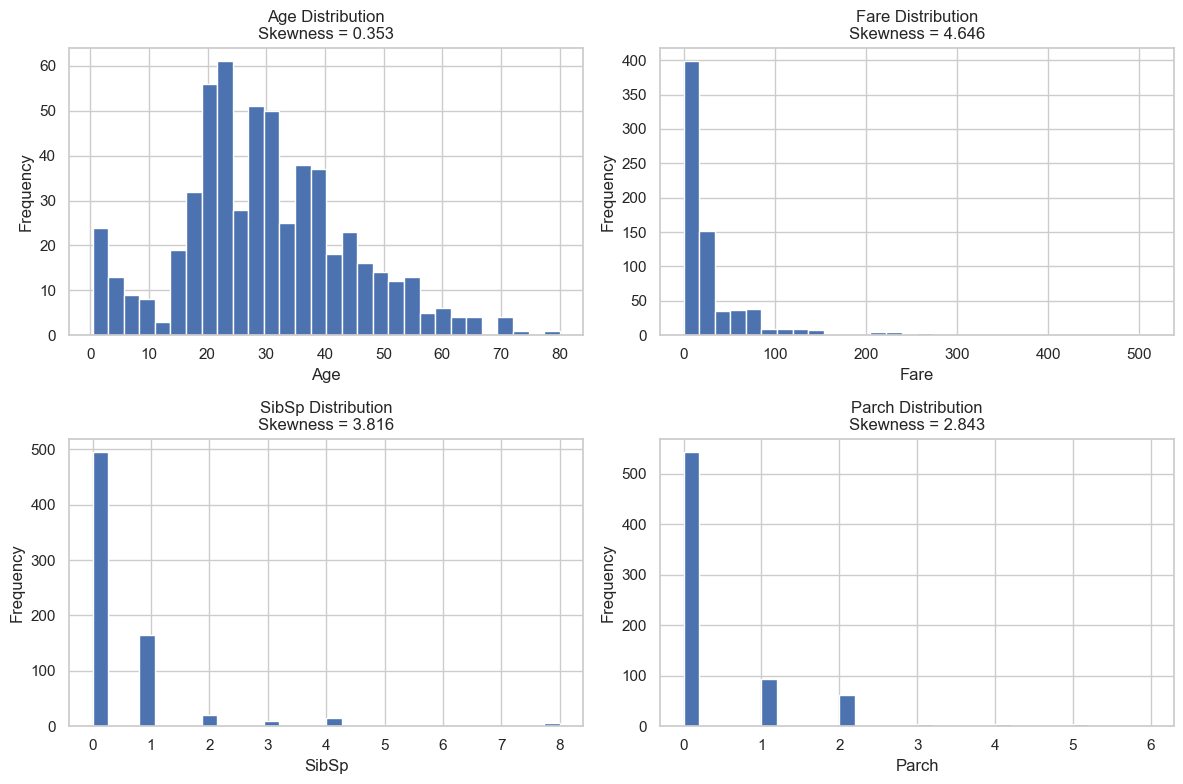

In [178]:
# ============================================
# SKEWNESS — TRAINING SET
# ============================================

numeric_features_to_check = [
    "Age",
    "Fare",
    "SibSp",
    "Parch"
]

# --------------------------------------------
# Calculate skewness
# --------------------------------------------

skewness_results = pd.DataFrame({
    "Feature": numeric_features_to_check,
    "Skewness": [
        X_train[column].skew()
        for column in numeric_features_to_check
    ]
})

skewness_results["Absolute Skewness"] = (
    skewness_results["Skewness"].abs()
)

skewness_results["Interpretation"] = np.where(
    skewness_results["Absolute Skewness"] < 0.5,
    "Approximately symmetric",
    np.where(
        skewness_results["Absolute Skewness"] < 1,
        "Moderately skewed",
        "Strongly skewed"
    )
)

# Display results
display(
    skewness_results.sort_values(
        "Absolute Skewness",
        ascending=False
    )
)

# --------------------------------------------
# Visualize distributions
# --------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8)
)

axes = axes.flatten()

for i, column in enumerate(numeric_features_to_check):

    axes[i].hist(
        X_train[column].dropna(),
        bins=30
    )

    skew_value = X_train[column].skew()

    axes[i].set_title(
        f"{column} Distribution\n"
        f"Skewness = {skew_value:.3f}"
    )

    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

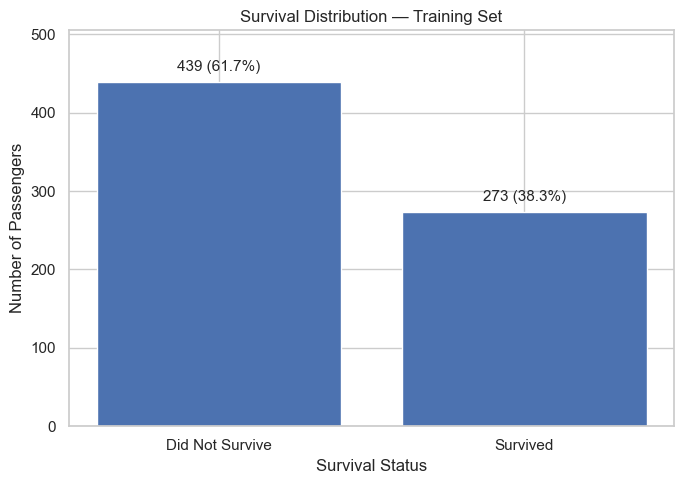

In [179]:
# ============================================
# TARGET DISTRIBUTION — TRAINING SET
# ============================================

survived_counts = y_train.value_counts().sort_index()
survived_percentages = (
    y_train.value_counts(normalize=True)
    .sort_index()
    * 100
)

labels = ["Did Not Survive", "Survived"]

plt.figure(figsize=(7, 5))

bars = plt.bar(
    labels,
    survived_counts.values
)

plt.title("Survival Distribution — Training Set")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")

for bar, count, percentage in zip(
    bars,
    survived_counts.values,
    survived_percentages.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f"{count} ({percentage:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.ylim(0, max(survived_counts.values) * 1.15)
plt.tight_layout()
plt.show()

# Feature Engineering 

In [180]:
# FEATURE ENGINEERING

def feature_engineer(df):
    df = df.copy()

    # ----------------------------
    # Fare transformation
    # ----------------------------
    df["FareLog"] = np.log1p(df["Fare"])

    # ----------------------------
    # Family features
    # ----------------------------
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

    df["IsAlone"] = (
        df["FamilySize"] == 1
    ).astype(int)

    # ----------------------------
    # Title from Name
    # ----------------------------
    df["Title"] = (
        df["Name"]
        .str.extract(r",\s*([^.]*)\.", expand=False)
        .str.strip()
    )

    # Standardize titles
    df["Title"] = df["Title"].replace({
        "Mlle": "Miss",
        "Ms": "Miss",
        "Mme": "Mrs"
    })

    # Keep common titles and group the rest
    df["Title"] = df["Title"].where(
        df["Title"].isin([
            "Mr",
            "Miss",
            "Mrs",
            "Master"
        ]),
        "Rare"
    )

    # ----------------------------
    # Deck from Cabin
    # ----------------------------
    df["Deck"] = (
        df["Cabin"]
        .fillna("Unknown")
        .str[0]
    )

    # ----------------------------
    # Cabin known indicator
    # ----------------------------
    df["CabinKnown"] = (
        df["Cabin"].notna()
    ).astype(int)

    # ----------------------------
    # Ticket prefix
    # ----------------------------
    df["TicketPrefix"] = (
        df["Ticket"]
        .str.replace(r"\d", "", regex=True)
        .str.replace(r"[\s./]+", "", regex=True)
        .str.upper()
    )

    df["TicketPrefix"] = df["TicketPrefix"].replace(
        "",
        "NUMERIC"
    )

    return df


X_train_fe = feature_engineer(X_train)
X_val_fe = feature_engineer(X_val)   # Feature engineering that uses fixed rules -> okay on val.

print("Training data after feature engineering:")
print(X_train_fe.shape)

print("\nValidation data after feature engineering:")
print(X_val_fe.shape)

Training data after feature engineering:
(712, 18)

Validation data after feature engineering:
(179, 18)


# Preprocessing and More Cleaning for Regressions

In [181]:
columns_to_drop = [
    "PassengerId",
    "Name",
    "Ticket",
    "Cabin",
    "SibSp",
    "Parch",
    "Fare"
]

X_train_model = X_train_fe.drop(columns=columns_to_drop)
X_val_model = X_val_fe.drop(columns=columns_to_drop)

# --------------------------------------------
# Define numerical and categorical features
# Avoid collinearity: FamilySize replaces SibSp/Parch; Deck replaces CabinKnown.
# --------------------------------------------

numerical_features = [
    "Age",
    "FareLog",
    "FamilySize"
]

categorical_features = [
    "Pclass",
    "Sex",
    "Embarked",
    "Title",
    "Deck",
    "TicketPrefix",
    "IsAlone"
]

# --------------------------------------------
# Numerical preprocessing
# --------------------------------------------

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# --------------------------------------------
# Categorical preprocessing
# --------------------------------------------

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

# --------------------------------------------
# Combine preprocessing
# --------------------------------------------

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

# Fit ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train_model)

# Apply the same preprocessing to validation data
X_val_processed = preprocessor.transform(X_val_model)

print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)

Processed training shape: (712, 44)
Processed validation shape: (179, 44)


## Before and after: missing-value imputation
Use the already fitted training preprocessors to show real missing values being filled. Age uses the training median; Embarked uses the training mode. Displayed values are before scaling or encoding. Nothing is fitted again, and validation data do not determine the replacements.

In [182]:
fitted_numeric = preprocessor.named_transformers_["num"]
fitted_categorical = preprocessor.named_transformers_["cat"]
numeric_imputed = pd.DataFrame(
    fitted_numeric.named_steps["imputer"].transform(X_train_model[numerical_features]),
    index=X_train_model.index, columns=numerical_features,
)
categorical_imputed = pd.DataFrame(
    fitted_categorical.named_steps["imputer"].transform(X_train_model[categorical_features]),
    index=X_train_model.index, columns=categorical_features,
)
imputation_examples = []
for column, filled, rule in [
    ("Age", numeric_imputed, "Training median"),
    ("Embarked", categorical_imputed, "Training mode"),
]:
    missing_ids = X_train_model.index[X_train_model[column].isna()]
    print(f"{column}: {len(missing_ids)} missing before; {filled[column].isna().sum()} missing after")
    for idx in missing_ids[:5]:
        imputation_examples.append({
            "PassengerId": X_train.loc[idx, "PassengerId"], "Feature": column,
            "Before": X_train_model.loc[idx, column], "After": filled.loc[idx, column], "Rule": rule,
        })
if imputation_examples:
    display(pd.DataFrame(imputation_examples))
else:
    print("No missing Age or Embarked values in this training split.")

Age: 137 missing before; 0 missing after
Embarked: 2 missing before; 0 missing after


,PassengerId,Feature,Before,After,Rule
0,693,Age,NaN,28.5000,Training median
1,482,Age,NaN,28.5000,Training median
2,528,Age,NaN,28.5000,Training median
3,558,Age,NaN,28.5000,Training median
4,829,Age,NaN,28.5000,Training median
5,830,Embarked,NaN,S,Training mode
6,62,Embarked,NaN,S,Training mode


## Before and after: scaling and categorical encoding
Scaling is shown separately from imputation: each numerical value below is already imputed before applying the training mean and standard deviation. For encoding, Sex illustrates the fitted one-hot encoder. With `drop="first"`, the omitted reference category is represented by zeros.

In [183]:
feature_example_ids = X_train_model.head(5).index
numeric_scaled = pd.DataFrame(
    fitted_numeric.named_steps["scaler"].transform(numeric_imputed),
    index=X_train_model.index, columns=numerical_features,
)
scaling_examples = pd.DataFrame({"PassengerId": X_train.loc[feature_example_ids, "PassengerId"]})
for column in numerical_features:
    scaling_examples[f"{column} before scaling"] = numeric_imputed.loc[feature_example_ids, column]
    scaling_examples[f"{column} after scaling"] = numeric_scaled.loc[feature_example_ids, column]
print("Numerical scaling: five training passengers")
display(scaling_examples)

fitted_encoder = fitted_categorical.named_steps["encoder"]
encoding_ids = categorical_imputed.drop_duplicates(subset=["Sex"]).index
encoded_examples = fitted_encoder.transform(categorical_imputed.loc[encoding_ids])
if hasattr(encoded_examples, "toarray"):
    encoded_examples = encoded_examples.toarray()
encoded_examples = pd.DataFrame(
    encoded_examples, index=encoding_ids,
    columns=fitted_encoder.get_feature_names_out(categorical_features),
)
sex_columns = [column for column in encoded_examples.columns if column.startswith("Sex_")]
encoding_examples = pd.DataFrame({
    "PassengerId": X_train.loc[encoding_ids, "PassengerId"],
    "Sex before encoding": categorical_imputed.loc[encoding_ids, "Sex"],
}).join(encoded_examples[sex_columns])
print("Categorical encoding: one passenger per observed Sex category")
display(encoding_examples)

Numerical scaling: five training passengers


,PassengerId,Age before scaling,Age after scaling,FareLog before scaling,FareLog after scaling,FamilySize before scaling,FamilySize after scaling
692,693,28.5000,-0.0811,4.0517,1.1246,1.0000,-0.5563
481,482,28.5000,-0.0811,0.0000,-3.0143,1.0000,-0.5563
527,528,28.5000,-0.0811,5.4062,2.5082,1.0000,-0.5563
855,856,18.0000,-0.8878,2.3370,-0.6270,2.0000,0.0734
801,802,31.0000,0.1109,3.3051,0.3619,3.0000,0.7032


Categorical encoding: one passenger per observed Sex category


,PassengerId,Sex before encoding,Sex_male
692,693,male,1.0000
855,856,female,0.0000


# Preprocessing and More Cleaning for BernoulliNB

In [184]:
columns_to_drop = [
    "PassengerId",
    "Name",
    "Ticket",
    "Cabin",
    "SibSp",
    "Parch",
    "Fare"
]

X_train_nb = X_train_fe.drop(columns=columns_to_drop)
X_val_nb = X_val_fe.drop(columns=columns_to_drop)

numerical_features = [
    "Age",
    "FareLog",
    "FamilySize"
]

categorical_features = [
    "Pclass",
    "Sex",
    "Embarked",
    "Title",
    "Deck",
    "TicketPrefix",
    "IsAlone"
]

nb_numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("bins", KBinsDiscretizer(
        n_bins=5,
        encode="onehot",
        strategy="quantile",
        subsample=None
    ))
])

nb_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [185]:
nb_preprocessor = ColumnTransformer([
    ("num", nb_numerical_pipeline, numerical_features),
    ("cat", nb_categorical_pipeline, categorical_features)
])

In [ ]:
X_train_nb_processed = nb_preprocessor.fit_transform(X_train_nb)

X_val_nb_processed = nb_preprocessor.transform(X_val_nb)

print("Training shape:", X_train_nb_processed.shape)
print("Validation shape:", X_val_nb_processed.shape)


# ============================================
# BERNOULLI NB — BEFORE AND AFTER PREPROCESSING
# ============================================

# Get the fitted preprocessing pipelines
fitted_nb_numeric = nb_preprocessor.named_transformers_["num"]
fitted_nb_categorical = nb_preprocessor.named_transformers_["cat"]

# --------------------------------------------
# 1. Numerical imputation examples
# --------------------------------------------

numeric_imputer = fitted_nb_numeric.named_steps["imputer"]

# Find training rows where Age was originally missing
missing_age_ids = X_train_nb.index[
    X_train_nb["Age"].isna()
][:5]

age_imputed = numeric_imputer.transform(
    X_train_nb.loc[missing_age_ids, numerical_features]
)

age_imputed_df = pd.DataFrame(
    age_imputed,
    index=missing_age_ids,
    columns=numerical_features
)

nb_imputation_examples = pd.DataFrame({
    "PassengerId": X_train.loc[missing_age_ids, "PassengerId"],
    "Age Before": X_train_nb.loc[missing_age_ids, "Age"].values,
    "Age After Imputation": age_imputed_df["Age"].values
})

print("BernoulliNB numerical imputation examples:")
display(nb_imputation_examples)


# --------------------------------------------
# 2. Numerical binning examples
# --------------------------------------------

numeric_binner = fitted_nb_numeric.named_steps["bins"]

# Select first five training passengers
example_ids = X_train_nb.index[:5]

numeric_imputed_examples = pd.DataFrame(
    numeric_imputer.transform(
        X_train_nb.loc[example_ids, numerical_features]
    ),
    index=example_ids,
    columns=numerical_features
)

numeric_binned = numeric_binner.transform(
    numeric_imputed_examples
)

if hasattr(numeric_binned, "toarray"):
    numeric_binned = numeric_binned.toarray()

numeric_feature_names = (
    numeric_binner.get_feature_names_out(numerical_features)
)

numeric_binned_df = pd.DataFrame(
    numeric_binned,
    index=example_ids,
    columns=numeric_feature_names
)

print("BernoulliNB numerical features after quantile binning:")
display(numeric_binned_df)


# --------------------------------------------
# 3. Categorical encoding examples
# --------------------------------------------

categorical_imputer = fitted_nb_categorical.named_steps["imputer"]
categorical_encoder = fitted_nb_categorical.named_steps["encoder"]

# Select examples containing different Sex values
sex_example_ids = (
    X_train_nb
    .dropna(subset=["Sex"])
    .groupby("Sex")
    .head(1)
    .index
)

categorical_imputed = categorical_imputer.transform(
    X_train_nb.loc[sex_example_ids, categorical_features]
)

categorical_imputed_df = pd.DataFrame(
    categorical_imputed,
    index=sex_example_ids,
    columns=categorical_features
)

categorical_encoded = categorical_encoder.transform(
    categorical_imputed_df
)

if hasattr(categorical_encoded, "toarray"):
    categorical_encoded = categorical_encoded.toarray()

categorical_feature_names = (
    categorical_encoder.get_feature_names_out(categorical_features)
)

categorical_encoded_df = pd.DataFrame(
    categorical_encoded,
    index=sex_example_ids,
    columns=categorical_feature_names
)

sex_columns = [
    col for col in categorical_encoded_df.columns
    if "Sex_" in col
]

nb_encoding_examples = pd.DataFrame({
    "PassengerId": X_train.loc[sex_example_ids, "PassengerId"],
    "Sex Before": X_train_nb.loc[sex_example_ids, "Sex"].values
}).join(
    categorical_encoded_df[sex_columns]
)

print("BernoulliNB categorical encoding examples:")
display(nb_encoding_examples)

Training shape: (712, 60)
Validation shape: (179, 60)
BernoulliNB numerical imputation examples:


,PassengerId,Age Before,Age After Imputation
692,693,NaN,28.5000
481,482,NaN,28.5000
527,528,NaN,28.5000
557,558,NaN,28.5000
828,829,NaN,28.5000


BernoulliNB numerical features after quantile binning:


,Age_0.0,Age_1.0,Age_2.0,Age_3.0,Age_4.0,FareLog_0.0,FareLog_1.0,FareLog_2.0,FareLog_3.0,FareLog_4.0,FamilySize_0.0,FamilySize_1.0
692,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000
481,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
527,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000
855,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000
801,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000


BernoulliNB categorical encoding examples:


,PassengerId,Sex Before,Sex_female,Sex_male
692,693,male,0.0000,1.0000
855,856,female,1.0000,0.0000


# Train and Evaluate BernoulliNB 

In [187]:
def evaluate_nb(alpha):
    
    # Create model
    model = BernoulliNB(alpha=alpha)
    
    # Train
    model.fit(X_train_nb_processed, y_train)
    
    # Predictions
    y_pred = model.predict(X_val_nb_processed)
    y_prob = model.predict_proba(X_val_nb_processed)[:, 1]
    
    # Metrics
    results = {
        "Alpha": alpha,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1": f1_score(y_val, y_pred),
        "AUC": roc_auc_score(y_val, y_prob)
    }
    
    return model, y_pred, y_prob, results

In [188]:
alphas = [0, 0.01, 1.0, 10]

nb_models = {}
nb_predictions = {}
nb_probabilities = {}
nb_results = []

for alpha in alphas:
    
    model, y_pred, y_prob, results = evaluate_nb(alpha)
    
    nb_models[alpha] = model
    nb_predictions[alpha] = y_pred
    nb_probabilities[alpha] = y_prob
    nb_results.append(results)

In [189]:
nb_results_df = pd.DataFrame(nb_results)
nb_results_df

,Alpha,Accuracy,Precision,Recall,F1,AUC
0,0.0000,0.7430,0.6386,0.7681,0.6974,0.7969
1,0.0100,0.7374,0.6341,0.7536,0.6887,0.8057
2,1.0000,0.7430,0.6386,0.7681,0.6974,0.8098
3,10.0000,0.7598,0.6711,0.7391,0.7034,0.8121


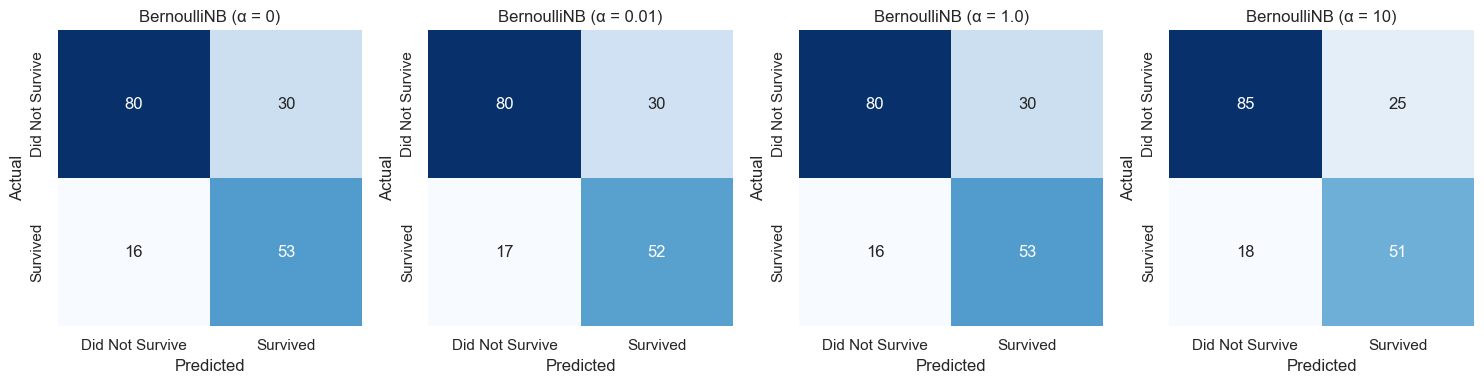

In [190]:
fig, axes = plt.subplots(1, len(alphas), figsize=(15, 4))

for ax, alpha in zip(axes, alphas):
    
    cm = confusion_matrix(
        y_val,
        nb_predictions[alpha]
    )
    
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=["Did Not Survive", "Survived"],
        yticklabels=["Did Not Survive", "Survived"]
    )
    
    ax.set_title(f"BernoulliNB (α = {alpha})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

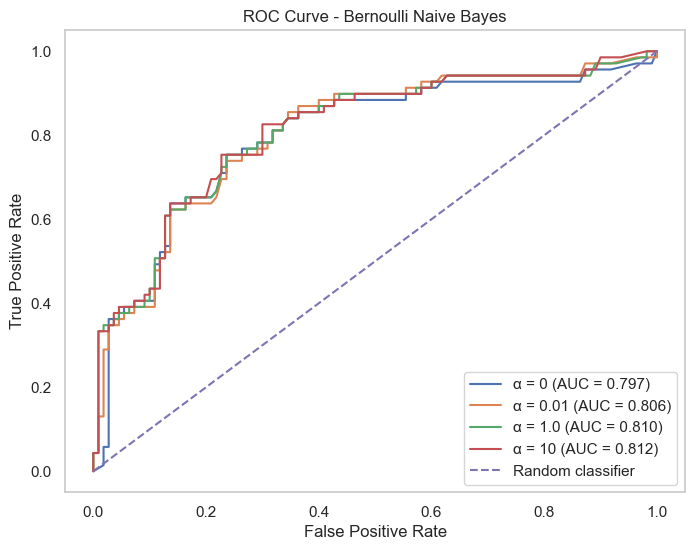

In [191]:
plt.figure(figsize=(8, 6))

for alpha in alphas:
    
    y_prob = nb_probabilities[alpha]
    
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    auc = roc_auc_score(y_val, y_prob)
    
    plt.plot(
        fpr,
        tpr,
        label=f"α = {alpha} (AUC = {auc:.3f})"
    )

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Bernoulli Naive Bayes")
plt.legend()
plt.grid()
plt.show()

# Train and Evaluate Regressions

In [192]:
# ============================================
# LINEAR REGRESSION
# ============================================

linear_model = LinearRegression()

linear_model.fit(
    X_train_processed,
    y_train
)

# Continuous prediction scores
linear_scores = linear_model.predict(X_val_processed)

# Convert scores to binary predictions using 0.5 threshold
linear_predictions = (
    linear_scores >= 0.5
).astype(int)

In [193]:
# ============================================
# RIDGE REGRESSION
# ============================================

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(
    X_train_processed,
    y_train
)

ridge_scores = ridge_model.predict(X_val_processed)

ridge_predictions = (
    ridge_scores >= 0.5
).astype(int)

In [194]:
# ============================================
# LASSO REGRESSION
# ============================================

lasso_model = Lasso(alpha=0.01)

lasso_model.fit(
    X_train_processed,
    y_train
)

lasso_scores = lasso_model.predict(X_val_processed)

lasso_predictions = (
    lasso_scores >= 0.5
).astype(int)

In [195]:
# ============================================
# EVALUATE REGRESSION MODELS
# ============================================

regression_models = {
    "Linear Regression": {
        "predictions": linear_predictions,
        "scores": linear_scores
    },
    "Ridge": {
        "predictions": ridge_predictions,
        "scores": ridge_scores
    },
    "LASSO": {
        "predictions": lasso_predictions,
        "scores": lasso_scores
    }
}

regression_results = []

for name, data in regression_models.items():

    predictions = data["predictions"]
    scores = data["scores"]

    regression_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, predictions),
        "Precision": precision_score(y_val, predictions),
        "Recall": recall_score(y_val, predictions),
        "F1": f1_score(y_val, predictions),
        "AUC": roc_auc_score(y_val, scores)
    })

regression_results_df = pd.DataFrame(regression_results)

regression_results_df

,Model,Accuracy,Precision,Recall,F1,AUC
0,Linear Regression,0.8380,0.8030,0.7681,0.7852,0.8706
1,Ridge,0.8212,0.7937,0.7246,0.7576,0.8693
2,LASSO,0.7933,0.7500,0.6957,0.7218,0.8487


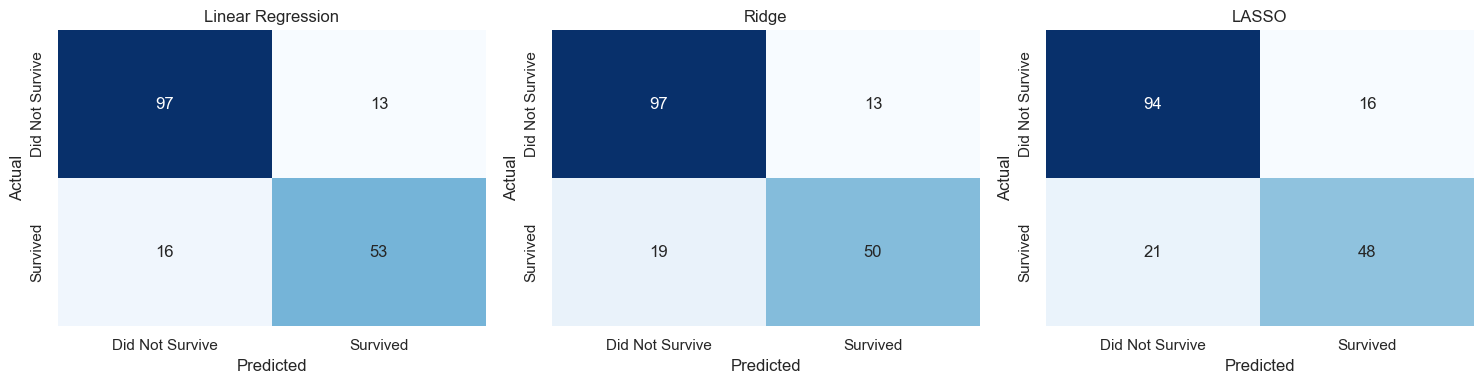

In [196]:
# ============================================
# CONFUSION MATRIX HEATMAPS
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, data) in zip(axes, regression_models.items()):

    cm = confusion_matrix(
        y_val,
        data["predictions"]
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=["Did Not Survive", "Survived"],
        yticklabels=["Did Not Survive", "Survived"]
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

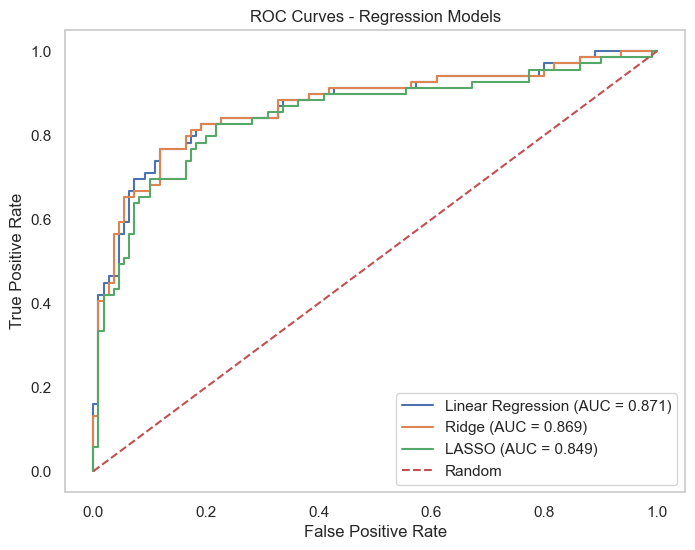

In [197]:
# ============================================
# ROC CURVES - ALL REGRESSION MODELS
# ============================================

plt.figure(figsize=(8, 6))

for name, data in regression_models.items():

    scores = data["scores"]

    fpr, tpr, _ = roc_curve(
        y_val,
        scores
    )

    auc = roc_auc_score(
        y_val,
        scores
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Regression Models")
plt.legend()
plt.grid()

plt.show()

# Prediction on Test Data

In [198]:
test_fe = feature_engineer(test)
train_fe = feature_engineer(train)

X_test_model = test_fe.drop(columns=columns_to_drop)

print("Test features:")
display(X_test_model.head())

Test features:


,Pclass,Sex,Age,Embarked,FareLog,FamilySize,IsAlone,Title,Deck,CabinKnown,TicketPrefix
0,3,male,34.5000,Q,2.1781,1.0000,1,Mr,U,0,NUMERIC
1,3,female,47.0000,S,2.0794,2.0000,0,Mrs,U,0,NUMERIC
2,2,male,62.0000,Q,2.3691,1.0000,1,Mr,U,0,NUMERIC
3,3,male,27.0000,S,2.2683,1.0000,1,Mr,U,0,NUMERIC
4,3,female,22.0000,S,2.5868,3.0000,0,Mrs,U,0,NUMERIC


In [199]:
X_full_model = train_fe.drop(columns=columns_to_drop)

print("Full training shape:", X_full_model.shape)
print("Test shape:", X_test_model.shape)

Full training shape: (891, 12)
Test shape: (418, 11)


In [200]:
final_preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

X_full_processed = final_preprocessor.fit_transform(
    X_full_model
)

X_test_processed = final_preprocessor.transform(
    X_test_model
)

In [201]:
final_linear_model = LinearRegression()

final_linear_model.fit(
    X_full_processed,
    train["Survived"]
)

LinearRegression()

In [202]:
# ============================================
# PREDICT TEST DATA
# ============================================

test_scores = final_linear_model.predict(
    X_test_processed
)

test_predictions = (
    test_scores >= 0.5
).astype(int)

# ============================================
# FINAL PREDICTIONS
# ============================================

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": test_predictions
})

submission.head(10)

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0
